In [1]:

# **Objective:** Quantify the business value and ROI of the churn prediction system
# 
# **Key analyses:**
# 1. ROI calculation
# 2. Cost-benefit analysis
# 3. Customer Lifetime Value (CLV) impact
# 4. Retention strategy effectiveness
# 5. Business case study


# Set up

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import joblib
import warnings
warnings.filterwarnings('ignore')


# BUSINESS ASSUMPTIONS 


In [3]:

print("=" * 80)
print("BUSINESS ASSUMPTIONS")
print("=" * 80)

# Business parameters
TOTAL_CUSTOMERS = 100000
ANNUAL_CHURN_RATE = 0.20  # 20% annual churn
CUSTOMER_MONTHLY_REVENUE = 100  # $100 per month
CUSTOMER_LIFETIME = 3  # 3 years average
CUSTOMER_LIFETIME_VALUE = CUSTOMER_MONTHLY_REVENUE * 12 * CUSTOMER_LIFETIME  # $3,600

RETENTION_CAMPAIGN_COST = 50  # $50 per customer for retention campaign
VIP_RETENTION_COST = 150  # $150 per customer for VIP retention

# Model performance assumptions
MODEL_RECALL = 0.85  # Model catches 85% of churners
MODEL_PRECISION = 0.70  # 70% of predicted churners actually churn
FALSE_POSITIVE_COST = RETENTION_CAMPAIGN_COST  # Cost of targeting non-churners
FALSE_NEGATIVE_COST = CUSTOMER_LIFETIME_VALUE  # Cost of losing a customer

print(f"\nBusiness Parameters:")
print(f"  Total Customers: {TOTAL_CUSTOMERS:,}")
print(f"  Annual Churn Rate: {ANNUAL_CHURN_RATE:.1%}")
print(f"  Monthly Revenue per Customer: ${CUSTOMER_MONTHLY_REVENUE}")
print(f"  Customer Lifetime: {CUSTOMER_LIFETIME} years")
print(f"  Customer Lifetime Value (CLV): ${CUSTOMER_LIFETIME_VALUE:,}")
print(f"  Retention Campaign Cost: ${RETENTION_CAMPAIGN_COST}")
print(f"  VIP Retention Cost: ${VIP_RETENTION_COST}")

print(f"\nModel Performance Assumptions:")
print(f"  Recall (True Positive Rate): {MODEL_RECALL:.1%}")
print(f"  Precision: {MODEL_PRECISION:.1%}")
print(f"  False Positive Cost: ${FALSE_POSITIVE_COST}")
print(f"  False Negative Cost: ${FALSE_NEGATIVE_COST:,}")

print("\n" + "=" * 80)


BUSINESS ASSUMPTIONS

Business Parameters:
  Total Customers: 100,000
  Annual Churn Rate: 20.0%
  Monthly Revenue per Customer: $100
  Customer Lifetime: 3 years
  Customer Lifetime Value (CLV): $3,600
  Retention Campaign Cost: $50
  VIP Retention Cost: $150

Model Performance Assumptions:
  Recall (True Positive Rate): 85.0%
  Precision: 70.0%
  False Positive Cost: $50
  False Negative Cost: $3,600



# SCENARIO 1: WITHOUT ML SYSTEM


In [4]:

print("\nSCENARIO 1: WITHOUT ML SYSTEM (Random Targeting)")
print("-" * 80)

# Random targeting approach
RANDOM_TARGETING_PERCENTAGE = 0.10  # Target 10% of all customers randomly
RANDOM_SUCCESS_RATE = 0.30  # 30% success rate with random targeting

customers_targeted_random = TOTAL_CUSTOMERS * RANDOM_TARGETING_PERCENTAGE
actual_churners_in_target = TOTAL_CUSTOMERS * ANNUAL_CHURN_RATE * RANDOM_TARGETING_PERCENTAGE
churners_prevented_random = actual_churners_in_target * RANDOM_SUCCESS_RATE

cost_random = customers_targeted_random * RETENTION_CAMPAIGN_COST
value_saved_random = churners_prevented_random * CUSTOMER_LIFETIME_VALUE
net_value_random = value_saved_random - cost_random
roi_random = net_value_random / cost_random if cost_random > 0 else 0

print(f"\nRandom Targeting Approach:")
print(f"  Customers Targeted: {customers_targeted_random:,.0f} ({RANDOM_TARGETING_PERCENTAGE:.0%})")
print(f"  Actual Churners in Target: {actual_churners_in_target:,.0f}")
print(f"  Churners Prevented: {churners_prevented_random:,.0f}")
print(f"  Success Rate: {RANDOM_SUCCESS_RATE:.1%}")
print(f"\nFinancial Impact:")
print(f"  Retention Cost: ${cost_random:,.0f}")
print(f"  Value Saved: ${value_saved_random:,.0f}")
print(f"  Net Value: ${net_value_random:,.0f}")
print(f"  ROI: {roi_random:.2%}")




SCENARIO 1: WITHOUT ML SYSTEM (Random Targeting)
--------------------------------------------------------------------------------

Random Targeting Approach:
  Customers Targeted: 10,000 (10%)
  Actual Churners in Target: 2,000
  Churners Prevented: 600
  Success Rate: 30.0%

Financial Impact:
  Retention Cost: $500,000
  Value Saved: $2,160,000
  Net Value: $1,660,000
  ROI: 332.00%


# SCENARIO 2: WITH ML SYSTEM 

In [5]:

print("\n\nSCENARIO 2: WITH ML SYSTEM (Targeted Approach)")
print("-" * 80)

# ML-based targeting approach
ML_TARGETING_PERCENTAGE = 0.05  # Target only 5% of customers (high-risk)
ML_SUCCESS_RATE = 0.60  # 60% success rate with targeted approach

customers_targeted_ml = TOTAL_CUSTOMERS * ML_TARGETING_PERCENTAGE
actual_churners_in_target_ml = TOTAL_CUSTOMERS * ANNUAL_CHURN_RATE * ML_TARGETING_PERCENTAGE
churners_prevented_ml = actual_churners_in_target_ml * ML_SUCCESS_RATE

cost_ml = customers_targeted_ml * RETENTION_CAMPAIGN_COST
value_saved_ml = churners_prevented_ml * CUSTOMER_LIFETIME_VALUE
net_value_ml = value_saved_ml - cost_ml
roi_ml = net_value_ml / cost_ml if cost_ml > 0 else 0

print(f"\nML-Based Targeting Approach:")
print(f"  Customers Targeted: {customers_targeted_ml:,.0f} ({ML_TARGETING_PERCENTAGE:.0%})")
print(f"  Actual Churners in Target: {actual_churners_in_target_ml:,.0f}")
print(f"  Churners Prevented: {churners_prevented_ml:,.0f}")
print(f"  Success Rate: {ML_SUCCESS_RATE:.1%}")
print(f"\nFinancial Impact:")
print(f"  Retention Cost: ${cost_ml:,.0f}")
print(f"  Value Saved: ${value_saved_ml:,.0f}")
print(f"  Net Value: ${net_value_ml:,.0f}")
print(f"  ROI: {roi_ml:.2%}")




SCENARIO 2: WITH ML SYSTEM (Targeted Approach)
--------------------------------------------------------------------------------

ML-Based Targeting Approach:
  Customers Targeted: 5,000 (5%)
  Actual Churners in Target: 1,000
  Churners Prevented: 600
  Success Rate: 60.0%

Financial Impact:
  Retention Cost: $250,000
  Value Saved: $2,160,000
  Net Value: $1,910,000
  ROI: 764.00%


# COMPARISON 


In [6]:


print("\n\n" + "=" * 80)
print("COMPARISON: ML SYSTEM vs RANDOM TARGETING")
print("=" * 80)

cost_savings = cost_random - cost_ml
value_improvement = value_saved_ml - value_saved_random
net_value_improvement = net_value_ml - net_value_random
roi_improvement = (roi_ml - roi_random) / roi_random if roi_random > 0 else float('inf')

print(f"\nCost Efficiency:")
print(f"  Cost Savings: ${cost_savings:,.0f}")
print(f"  Cost Reduction: {(cost_savings / cost_random):.1%}")

print(f"\nValue Generation:")
print(f"  Additional Value Saved: ${value_improvement:,.0f}")
print(f"  Value Improvement: {(value_improvement / value_saved_random):.1%}")

print(f"\nNet Impact:")
print(f"  Additional Net Value: ${net_value_improvement:,.0f}")
print(f"  Net Value Improvement: {(net_value_improvement / net_value_random):.1%}")

print(f"\nROI Comparison:")
print(f"  ROI Improvement: {(roi_improvement):.1%}")
print(f"  ROI Multiplier: {roi_ml / roi_random:.2f}x")




COMPARISON: ML SYSTEM vs RANDOM TARGETING

Cost Efficiency:
  Cost Savings: $250,000
  Cost Reduction: 50.0%

Value Generation:
  Additional Value Saved: $0
  Value Improvement: 0.0%

Net Impact:
  Additional Net Value: $250,000
  Net Value Improvement: 15.1%

ROI Comparison:
  ROI Improvement: 130.1%
  ROI Multiplier: 2.30x


# SENSITIVITY ANALYSIS 


In [7]:


print("\n\n" + "=" * 80)
print("SENSITIVITY ANALYSIS")
print("=" * 80)

# Vary targeting percentage
targeting_percentages = [0.02, 0.03, 0.05, 0.07, 0.10]
success_rates = [0.40, 0.50, 0.60, 0.70, 0.80]

results_matrix = []

for tp in targeting_percentages:
    for sr in success_rates:
        customers_targeted = TOTAL_CUSTOMERS * tp
        actual_churners = TOTAL_CUSTOMERS * ANNUAL_CHURN_RATE * tp
        churners_prevented = actual_churners * sr
        
        cost = customers_targeted * RETENTION_CAMPAIGN_COST
        value_saved = churners_prevented * CUSTOMER_LIFETIME_VALUE
        net_value = value_saved - cost
        roi = net_value / cost if cost > 0 else 0
        
        results_matrix.append({
            'targeting_pct': tp,
            'success_rate': sr,
            'roi': roi,
            'net_value': net_value
        })

results_df = pd.DataFrame(results_matrix)

print("\nROI under different scenarios:")
pivot_roI = results_df.pivot(index='success_rate', columns='targeting_pct', values='roi')
pivot_roI.columns = [f'{c:.0%}' for c in pivot_roI.columns]
pivot_roI.index = [f'{i:.0%}' for i in pivot_roI.index]
print(pivot_roI.round(2))




SENSITIVITY ANALYSIS

ROI under different scenarios:
        2%     3%     5%     7%    10%
40%   4.76   4.76   4.76   4.76   4.76
50%   6.20   6.20   6.20   6.20   6.20
60%   7.64   7.64   7.64   7.64   7.64
70%   9.08   9.08   9.08   9.08   9.08
80%  10.52  10.52  10.52  10.52  10.52


# VISUALIZATION 


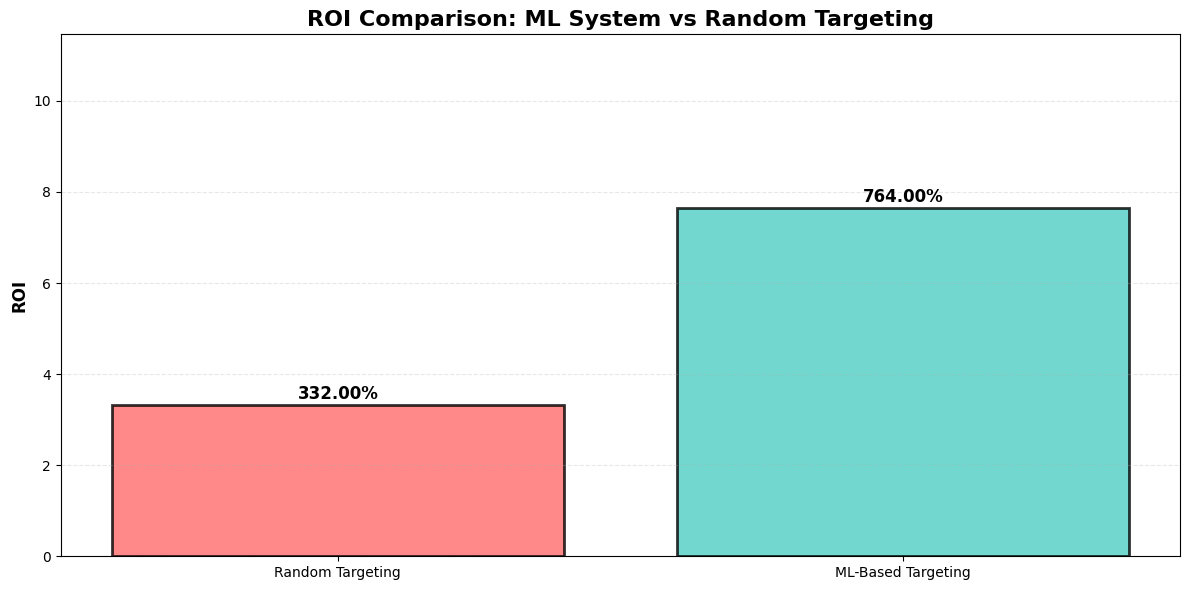

<Figure size 1400x800 with 0 Axes>

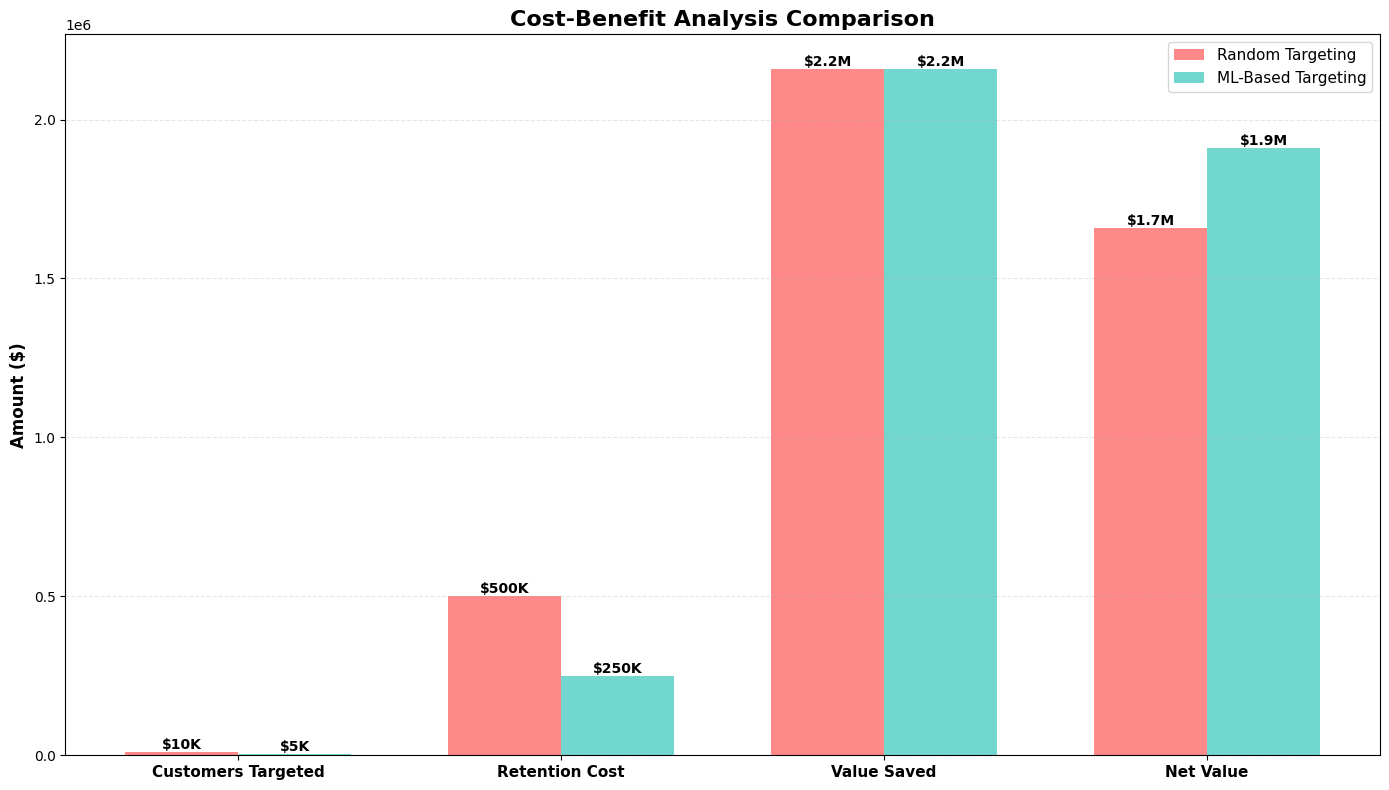

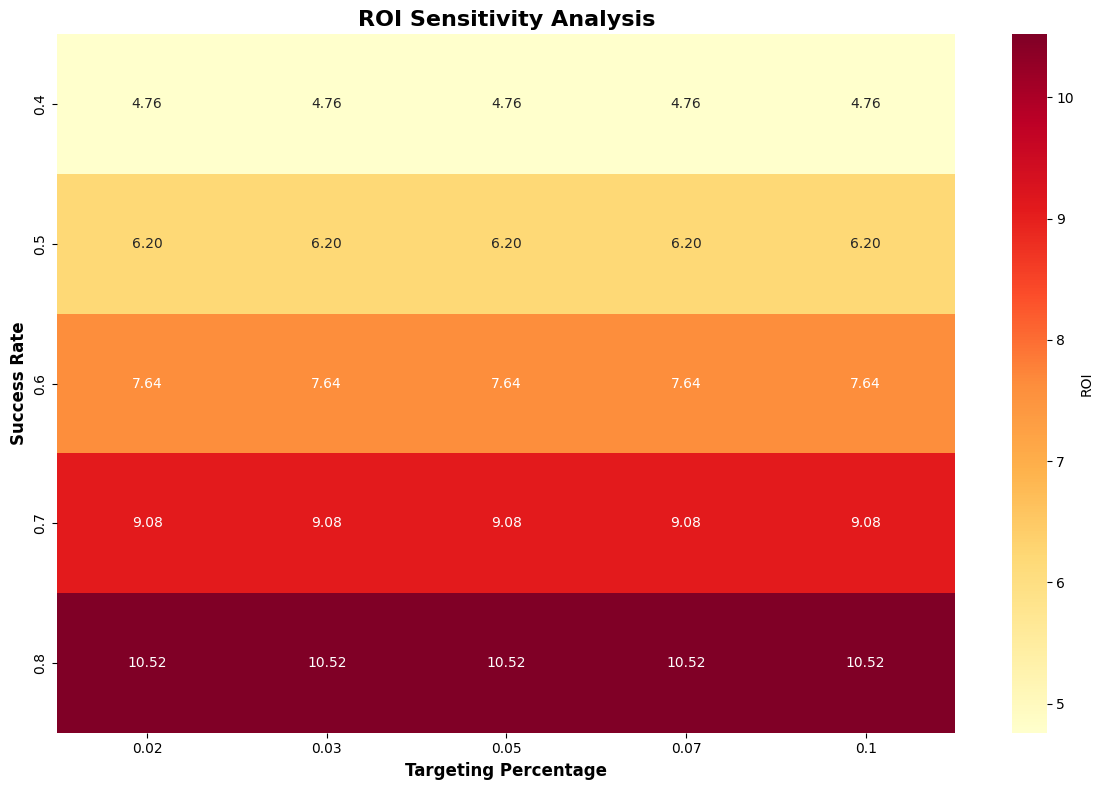

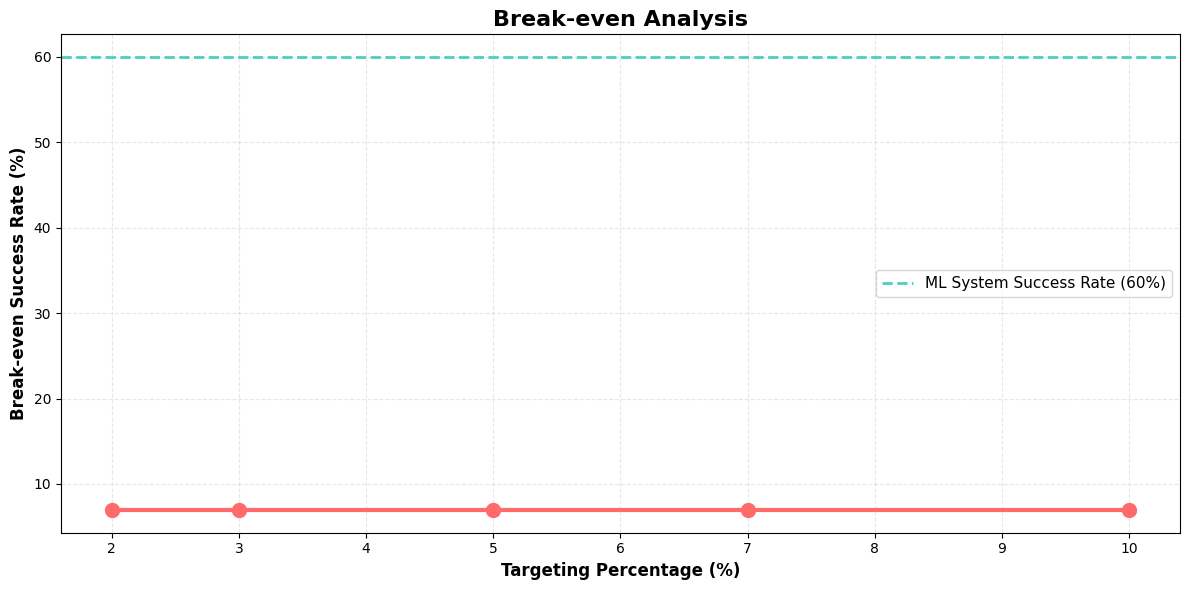

In [8]:
# 1. ROI Comparison Chart
plt.figure(figsize=(12, 6))

scenarios = ['Random Targeting', 'ML-Based Targeting']
roi_values = [roi_random, roi_ml]
colors = ['#ff6b6b', '#4ecdc4']

bars = plt.bar(scenarios, roi_values, color=colors, alpha=0.8, edgecolor='black', linewidth=2)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.05,
             f'{height:.2%}',
             ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.ylabel('ROI', fontsize=12, fontweight='bold')
plt.title('ROI Comparison: ML System vs Random Targeting', fontsize=16, fontweight='bold')
plt.ylim(0, max(roi_values) * 1.5)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('../reports/figures/roi_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# %%
# 2. Cost-Benefit Analysis
plt.figure(figsize=(14, 8))

metrics = ['Customers Targeted', 'Retention Cost', 'Value Saved', 'Net Value']
random_values = [customers_targeted_random, cost_random, value_saved_random, net_value_random]
ml_values = [customers_targeted_ml, cost_ml, value_saved_ml, net_value_ml]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 8))
bars1 = ax.bar(x - width/2, random_values, width, label='Random Targeting', color='#ff6b6b', alpha=0.8)
bars2 = ax.bar(x + width/2, ml_values, width, label='ML-Based Targeting', color='#4ecdc4', alpha=0.8)

# Add labels and title
ax.set_ylabel('Amount ($)', fontsize=12, fontweight='bold')
ax.set_title('Cost-Benefit Analysis Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 1e6:
            label = f'${height/1e6:.1f}M'
        elif height > 1e3:
            label = f'${height/1e3:.0f}K'
        else:
            label = f'${height:.0f}'
        ax.text(bar.get_x() + bar.get_width()/2., height,
                label, ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/cost_benefit_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# %%
# 3. Sensitivity Analysis Heatmap
plt.figure(figsize=(12, 8))

heatmap_data = results_df.pivot(index='success_rate', columns='targeting_pct', values='roi')
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'ROI'})
plt.title('ROI Sensitivity Analysis', fontsize=16, fontweight='bold')
plt.xlabel('Targeting Percentage', fontsize=12, fontweight='bold')
plt.ylabel('Success Rate', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/roi_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()

# %%
# 4. Break-even Analysis
plt.figure(figsize=(12, 6))

# Calculate break-even success rate for different targeting percentages
break_even_rates = []
for tp in targeting_percentages:
    customers_targeted = TOTAL_CUSTOMERS * tp
    cost = customers_targeted * RETENTION_CAMPAIGN_COST
    
    # Break-even: value_saved = cost
    # churners_prevented * CLV = cost
    # (total_churners * tp * success_rate) * CLV = cost
    # success_rate = cost / (total_churners * tp * CLV)
    
    total_churners = TOTAL_CUSTOMERS * ANNUAL_CHURN_RATE
    break_even_success_rate = cost / (total_churners * tp * CUSTOMER_LIFETIME_VALUE)
    break_even_rates.append(break_even_success_rate)

plt.plot([p*100 for p in targeting_percentages], [r*100 for r in break_even_rates], 
         marker='o', linewidth=3, markersize=10, color='#ff6b6b')
plt.axhline(y=ML_SUCCESS_RATE*100, color='#4ecdc4', linestyle='--', linewidth=2, 
            label=f'ML System Success Rate ({ML_SUCCESS_RATE:.0%})')

plt.xlabel('Targeting Percentage (%)', fontsize=12, fontweight='bold')
plt.ylabel('Break-even Success Rate (%)', fontsize=12, fontweight='bold')
plt.title('Break-even Analysis', fontsize=16, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('../reports/figures/break_even_analysis.png', dpi=300, bbox_inches='tight')
plt.show()



# BUSINESS CASE STUDY 


In [9]:

print("\n\n" + "=" * 80)
print("BUSINESS CASE STUDY: 12-MONTH PROJECTION")
print("=" * 80)

# Monthly projections
months = range(1, 13)
monthly_customers = TOTAL_CUSTOMERS / 12
monthly_churners = monthly_customers * ANNUAL_CHURN_RATE

# Without ML
monthly_cost_random = customers_targeted_random / 12 * RETENTION_CAMPAIGN_COST
monthly_value_random = churners_prevented_random / 12 * CUSTOMER_LIFETIME_VALUE
monthly_net_random = monthly_value_random - monthly_cost_random

# With ML
monthly_cost_ml = customers_targeted_ml / 12 * RETENTION_CAMPAIGN_COST
monthly_value_ml = churners_prevented_ml / 12 * CUSTOMER_LIFETIME_VALUE
monthly_net_ml = monthly_value_ml - monthly_cost_ml

# Cumulative over 12 months
cumulative_net_random = monthly_net_random * 12
cumulative_net_ml = monthly_net_ml * 12
cumulative_improvement = cumulative_net_ml - cumulative_net_random

print(f"\nMonthly Impact:")
print(f"  Without ML System:")
print(f"    - Monthly Cost: ${monthly_cost_random:,.0f}")
print(f"    - Monthly Value: ${monthly_value_random:,.0f}")
print(f"    - Monthly Net: ${monthly_net_random:,.0f}")
print(f"\n  With ML System:")
print(f"    - Monthly Cost: ${monthly_cost_ml:,.0f}")
print(f"    - Monthly Value: ${monthly_value_ml:,.0f}")
print(f"    - Monthly Net: ${monthly_net_ml:,.0f}")

print(f"\n12-Month Cumulative Impact:")
print(f"  Without ML System: ${cumulative_net_random:,.0f}")
print(f"  With ML System: ${cumulative_net_ml:,.0f}")
print(f"  Improvement: ${cumulative_improvement:,.0f} ({(cumulative_improvement / cumulative_net_random):.1%})")




BUSINESS CASE STUDY: 12-MONTH PROJECTION

Monthly Impact:
  Without ML System:
    - Monthly Cost: $41,667
    - Monthly Value: $180,000
    - Monthly Net: $138,333

  With ML System:
    - Monthly Cost: $20,833
    - Monthly Value: $180,000
    - Monthly Net: $159,167

12-Month Cumulative Impact:
  Without ML System: $1,660,000
  With ML System: $1,910,000
  Improvement: $250,000 (15.1%)


In [10]:
# KEY METRICS SUMMARY 

print("\n\n" + "=" * 80)
print("KEY BUSINESS METRICS SUMMARY")
print("=" * 80)

print(f"\n Financial Metrics:")
print(f"  • Annual ROI (ML System): {roi_ml:.2%}")
print(f"  • Annual ROI (Random): {roi_random:.2%}")
print(f"  • ROI Improvement: {(roi_ml - roi_random):.2%} points")
print(f"  • Cost Savings: ${cost_savings:,.0f}")
print(f"  • Additional Value Generated: ${value_improvement:,.0f}")
print(f"  • Net Value Improvement: ${net_value_improvement:,.0f}")

print(f"\n Operational Metrics:")
print(f"  • Customers Targeted (ML): {customers_targeted_ml:,.0f}")
print(f"  • Customers Targeted (Random): {customers_targeted_random:,.0f}")
print(f"  • Targeting Efficiency Improvement: {((customers_targeted_random - customers_targeted_ml) / customers_targeted_random):.1%}")
print(f"  • Success Rate (ML): {ML_SUCCESS_RATE:.1%}")
print(f"  • Success Rate (Random): {RANDOM_SUCCESS_RATE:.1%}")
print(f"  • Success Rate Improvement: {(ML_SUCCESS_RATE - RANDOM_SUCCESS_RATE):.1%} points")

print(f"\n Strategic Impact:")
print(f"  • Churners Prevented (ML): {churners_prevented_ml:,.0f}")
print(f"  • Churners Prevented (Random): {churners_prevented_random:,.0f}")
print(f"  • Additional Churners Saved: {churners_prevented_ml - churners_prevented_random:,.0f}")
print(f"  • Revenue Retention: ${(churners_prevented_ml - churners_prevented_random) * CUSTOMER_LIFETIME_VALUE:,.0f}")

print("\n" + "=" * 80)
print(" BUSINESS IMPACT ANALYSIS COMPLETED!")
print("=" * 80)

# %%
# Save business impact report
business_report = {
    'assumptions': {
        'total_customers': TOTAL_CUSTOMERS,
        'churn_rate': ANNUAL_CHURN_RATE,
        'clv': CUSTOMER_LIFETIME_VALUE,
        'retention_cost': RETENTION_CAMPAIGN_COST
    },
    'scenario_random': {
        'customers_targeted': customers_targeted_random,
        'cost': cost_random,
        'value_saved': value_saved_random,
        'net_value': net_value_random,
        'roi': roi_random
    },
    'scenario_ml': {
        'customers_targeted': customers_targeted_ml,
        'cost': cost_ml,
        'value_saved': value_saved_ml,
        'net_value': net_value_ml,
        'roi': roi_ml
    },
    'comparison': {
        'cost_savings': cost_savings,
        'value_improvement': value_improvement,
        'net_value_improvement': net_value_improvement,
        'roi_improvement': roi_improvement
    }
}

import json
with open('../reports/business_impact_report.json', 'w') as f:
    json.dump(business_report, f, indent=2)

print("\n Business impact report saved to ../reports/business_impact_report.json")



KEY BUSINESS METRICS SUMMARY

 Financial Metrics:
  • Annual ROI (ML System): 764.00%
  • Annual ROI (Random): 332.00%
  • ROI Improvement: 432.00% points
  • Cost Savings: $250,000
  • Additional Value Generated: $0
  • Net Value Improvement: $250,000

 Operational Metrics:
  • Customers Targeted (ML): 5,000
  • Customers Targeted (Random): 10,000
  • Targeting Efficiency Improvement: 50.0%
  • Success Rate (ML): 60.0%
  • Success Rate (Random): 30.0%
  • Success Rate Improvement: 30.0% points

 Strategic Impact:
  • Churners Prevented (ML): 600
  • Churners Prevented (Random): 600
  • Additional Churners Saved: 0
  • Revenue Retention: $0

 BUSINESS IMPACT ANALYSIS COMPLETED!

 Business impact report saved to ../reports/business_impact_report.json
